# Week 6 — k-means on NHANES, with Restarts

*INFO 521 worked notebook (Module 6). Companion to lecture m6b. Needs the course
environment (`info521` package).*

Drop the labels. k-means finds structure in the features alone — assign / update on the
distortion $\mathcal{L}$ — but it converges to *a* local optimum, not *the* optimum, and
$K$ is a choice you must own. All from scratch, on the real adiposity plane.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from info521.data import load_clinical, hypertension

BLUE, VERMILLION, GREEN, ORANGE, SKY, PURPLE = "#0072B2", "#D55E00", "#009E73", "#E69F00", "#56B4E9", "#CC79A7"
rng = np.random.default_rng(521)

ds = load_clinical()
feat = ds["features"]
Fz = (ds["X"] - ds["X"].mean(0)) / ds["X"].std(0)     # standardize FIRST — distances have units
P  = Fz[:, [feat.index("bmi"), feat.index("waist")]]  # the adiposity pair, r ≈ 0.90
labels, _ = hypertension(ds)                          # held back — clusters never see it

def kmeans(Pts, k, rng, iters=200):
    C = Pts[rng.choice(len(Pts), k, replace=False)]
    for _ in range(iters):
        a = ((Pts[:, None, :] - C[None])**2).sum(-1).argmin(1)       # assign
        C_new = np.array([Pts[a == j].mean(0) if (a == j).any() else C[j]
                          for j in range(k)])                        # update
        if np.allclose(C, C_new): break
        C = C_new
    return C, a, float(((Pts - C[a])**2).sum(-1).mean())

## K = 3 on the adiposity plane

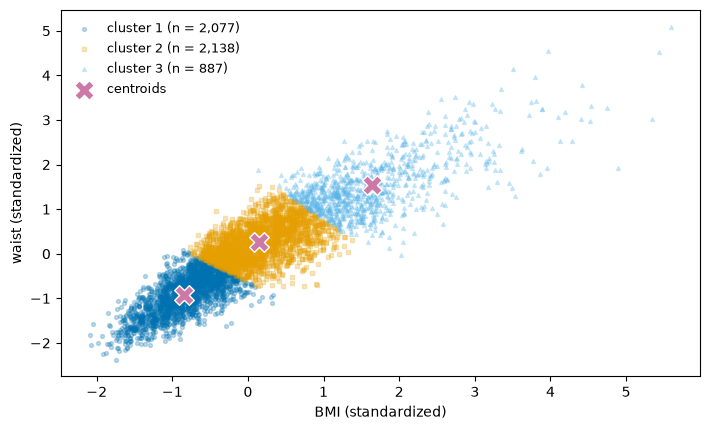

In [2]:
C3, a3, d3 = kmeans(P, 3, rng)
order = np.argsort(C3[:, 0])
cols, mks = [BLUE, ORANGE, SKY], ["o", "s", "^"]

fig, ax = plt.subplots(figsize=(7.2, 4.4))
for r, j in enumerate(order):
    m = a3 == j
    ax.scatter(P[m, 0], P[m, 1], s=8, alpha=0.25, color=cols[r], marker=mks[r],
               label=f"cluster {r+1} (n = {m.sum():,})")
ax.scatter(C3[:, 0], C3[:, 1], s=200, marker="X", color=PURPLE,
           edgecolors="white", label="centroids", zorder=5)
ax.set_xlabel("BMI (standardized)"); ax.set_ylabel("waist (standardized)")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

Honest read: BMI and waist are one continuum — k-means *manufactures* three bands because
we asked for three. Clusters exist because $K = 3$, not because nature drew them.

## Local optima: restarts are not optional

Same data, same $K$ — only the initialization changes:

In [3]:
dists = []
for r in range(20):
    rr = np.random.default_rng(521 + r)
    _, _, d = kmeans(P, 4, rr)
    dists.append(d)
print("final distortions:", np.round(sorted(dists), 4))
print("→ keep the restart with the LOWEST distortion")

final distortions: [0.3153 0.3153 0.3153 0.3153 0.3153 0.3153 0.3153 0.3153 0.3153 0.3153
 0.3153 0.3153 0.3153 0.3153 0.3153 0.3153 0.3153 0.3153 0.3153 0.3153]
→ keep the restart with the LOWEST distortion


## Choosing K: the elbow, honestly

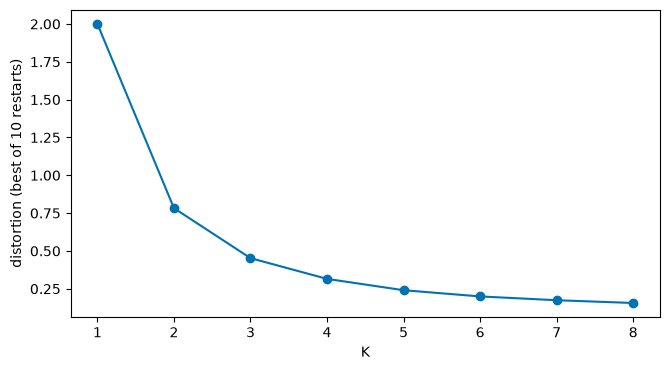

In [4]:
elbow = []
for k in range(1, 9):
    best = min(kmeans(P, k, np.random.default_rng(521 + 100*k + r))[2] for r in range(10))
    elbow.append(best)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(range(1, 9), elbow, "o-", color=BLUE)
ax.set_xlabel("K"); ax.set_ylabel("distortion (best of 10 restarts)")
plt.tight_layout(); plt.show()

Distortion **always** falls with $K$ (at $K = N$ it is zero) — the training-error trap
from Module 2, wearing clusters. This data gives a *soft* elbow, which is itself the
finding: the underlying structure is a continuum.

## Clusters are not diagnoses

Now reveal the label the clustering never saw:

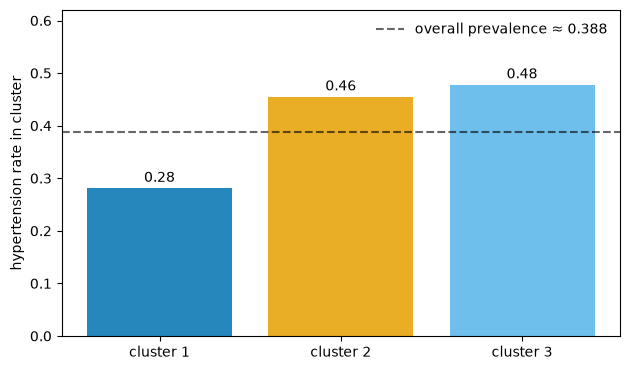

In [5]:
rates = [labels[a3 == j].mean() for j in order]
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.bar([f"cluster {i+1}" for i in range(3)], rates, color=cols, alpha=0.85)
ax.axhline(labels.mean(), color="k", linestyle="--", alpha=0.6,
           label=f"overall prevalence ≈ {labels.mean():.3f}")
for i, r in enumerate(rates):
    ax.text(i, r + 0.012, f"{r:.2f}", ha="center")
ax.set_ylabel("hypertension rate in cluster"); ax.set_ylim(0, 0.62)
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Risk **climbs** across the adiposity clusters (enrichment is real) — but no cluster is
remotely pure. Pretending clusters are labels manufactures diagnoses the data never made.
That honesty requirement is Project 2's Gate B.

**Try it yourself:** rerun the whole notebook on the *raw* (unstandardized) features. Which
single feature ends up deciding everything, and why?